In [1]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import time
import matplotlib.pyplot as plt

In [2]:
tau = [jnp.linspace(0, 20, 41),
       jnp.linspace(0, 20, 41)]

hyperparameters = {
    "theta" : jnp.array([0.2, 0.2, 3.0]),
    "X0" : jnp.array([-1.0, 1.0]),
    "sigma" : jnp.array([0.2, 0.2]),
    "tau" : tau,
    # "obs_times" : test_helpers.obs_matrix(tau),
    "I" : jnp.linspace(0, 20, int(160 +1))
}

def ode(X, theta, t=None):
    '''
    X : n x D
    theta : p

    return : n x D
    '''
    n = X.shape[0]
    V, R = X.T
    a, b, c = theta # theta.repeat([n, 1]).T

    return jnp.stack([c * (V - V**3/3 + R),
                        -1/c * (V - a + b*R)])

In [3]:
data = pd.read_csv('y.csv').to_numpy()
I = np.arange(0, 20.1, 0.125)
full = np.full((I.shape[0], data.shape[1]), np.nan)
full[:,0] = I
full[np.isin(full[:,0], data[:,0])] = data

In [4]:
from magi import MAGI

In [5]:
solver = MAGI(ode, full, [1, 1, 1], theta_conf=[0,0,0], sigmas=[0.2, 0.2])

In [6]:
solver.device_put(jax.devices()[0])

In [7]:
sd_init = 0.01
x0 = jr.normal(jr.PRNGKey(20), shape=(200, solver.particles_init.shape[0])) * sd_init + solver.particles_init
x0 = x0.at[:,-2:].set(jnp.abs(x0[:,-2:]))

In [8]:
start = time.time()
solver.solve(x0, mitosis_splits=2, optimizer_kwargs={'learning_rate': 0.1}, atol=0.1, rtol=0)
end = time.time()
print(f"Elapsed time: {end - start:.4f}")

Split 0 finished after 10000 iterations | max grad = 11226480827316811333632.00000
Split 1 finished after 10000 iterations | max grad = 57561547168936231960576.00000
Split 2 finished after 10000 iterations | max grad = 517708701090990002274304.00000
Elapsed time: 14.1826


# Seems like initialization is wrong

In [9]:
particles = solver.particles
theta = particles[:,:solver.p] # (p,)
X = jnp.reshape(particles[:,solver.p:solver.p+solver.D*solver.n], (particles.shape[0], solver.n, solver.D)) # (n, d)
# sigmas = solver.sigmas.at[:,solver.unknown_sigmas].set(jnp.clip(particles[:,solver.p+solver.D*solver.n:], min=1e-5)) # (d,)

In [10]:
particles.shape

(800, 325)

In [11]:
theta.mean(axis=0)

Array([-1833.4594 ,   -44.56918,   101.7699 ], dtype=float32)

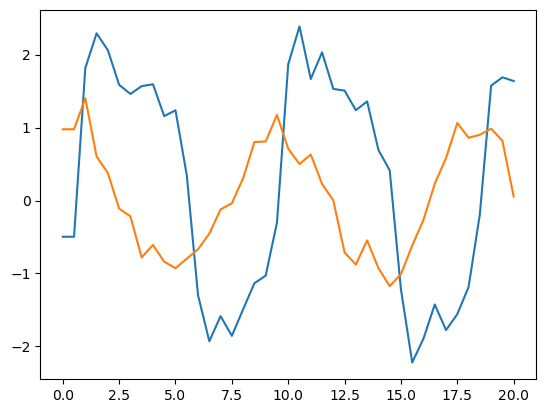

In [12]:
plt.plot(solver.I,  jnp.reshape(solver.particles_init[solver.p:solver.p+solver.D*solver.n], (solver.n, solver.D)) )

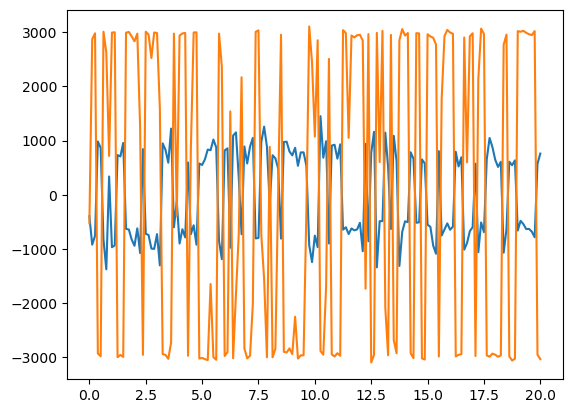

In [13]:
plt.plot(solver.I, X.mean(axis=0)[:,0])
plt.plot(solver.I, X.mean(axis=0)[:,1])